In [1]:
# Correctly import the ProjectManager class
from src.project_manager import ProjectManager
import sys
import os

# Ensure the src and ux_ui directories are in the Python path
sys.path.append(os.path.abspath('./src'))
sys.path.append(os.path.abspath('./ux_ui'))

# Initialize the ProjectManager with the base directory
base_directory = '../data/v3.0_las_files'
project_manager_instance = ProjectManager(base_directory)
project_manager_instance.selected_field = 'Scoda'

# Load the project with progress callback (set to None since we're not using UI)
project = project_manager_instance.load_selected_field(progress_callback=None)

project_manager_instance.selected_curves = ['DCAL', 'SCAL', 'MCAL', 'GR', 'SP', 'MN', 'MI',
                                            'RILM', 'RILD', 'RLL3', 'RXORT', 'RHOB', 'RHOC', 'CILD', 'DPOR', 'SPOR', 'DT', 'CNLS']

project_manager_instance.standardized_curve_mapping = {
    'Cali': ['DCAL', 'SCAL', 'MCAL'],
    'GR-SP': ['GR', 'SP'],
    'Micro': ['MN', 'MI'],
    'RIL': ['RILM', 'RILD', 'RLL3', 'RXORT'],
    'Density': ['RHOB', 'RHOC', 'CILD', 'DPOR'],
    'Sonic': ['SPOR', 'DT'],
    'Neutron': ['CNLS']
}

# Run funtion to determined outliers
project_manager_instance.detect_all_outliers()

# Filter outliers (make sure to call the method with parentheses)
project_manager_instance.prepare_data()

data = project_manager_instance.prepared_data
selected_curves = ['Cali', 'GR', 'SP', 'MN', 'MI', 'RILM', 'RILD',
                   'RLL3', 'RXORT', 'RHOB', 'RHOC', 'CILD', 'DPOR', 'SPOR', 'DT']
curves_to_predict = ['CNLS', 'Formation']
unique_formations = project_manager_instance.unique_formations


Data has been prepared successfully.


In [2]:
from src.neural_network.pipeline import pipeline
from src.neural_network.hyperparameters import *


(        data_corrected, correction_report,                                          # Step 0.5
        train_validation_data, external_test_data, discarded_wells,                 # Step 1
        engineered_data, feature_info, final_cols,                                  # Step 2 
        X_scaled, y_scaled, per_well_strategies, global_feature_scalers,            # Step 3
            categorical_encoders, column_types, feature_columns, global_columns, 
            well_descriptors, target_scalers, formation_encoder, unknown_index, 
            normalizers, fit_errors,
        top_configs, study,                                                         # Step 4
        # best_config, cv_results, best_model,                                        # Step 5
        # model, history,                                                             # Step 6
        # predictions,                                                                # Step 7


) = pipeline(
data, selected_curves, curves_to_predict)

    

2025-05-31 17:24:27,358 - src.utils.initialize_gpu - INFO - Step GPU-0: Configurando variables de entorno para RTX 4080...
2025-05-31 17:24:27,358 - src.utils.initialize_gpu - INFO - ✅ RTX 4080 optimizations applied:
2025-05-31 17:24:27,359 - src.utils.initialize_gpu - INFO -    • XLA compilation disabled
2025-05-31 17:24:27,359 - src.utils.initialize_gpu - INFO -    • Mixed precision disabled
2025-05-31 17:24:27,359 - src.utils.initialize_gpu - INFO -    • Async memory allocation
2025-05-31 17:24:27,359 - src.utils.initialize_gpu - INFO -    • Optimized thread parallelism
2025-05-31 17:24:27,360 - src.utils.initialize_gpu - INFO -    • CUDA caching enabled
2025-05-31 17:24:27,360 - src.utils.initialize_gpu - INFO - Inicialización de entorno GPU completada. Ahora puedes importar TensorFlow de manera segura.
2025-05-31 17:24:28.451160: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is

  0%|          | 0/1 [00:00<?, ?it/s]

2025-05-31 17:25:25.286105: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:57] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. model/dropout_1/dropout/random_uniform/RandomUniform
/usr/local/lib/python3.10/dist-packages/optuna_integration/tfkeras/tfkeras.py:53: UserWarning: The metric 'val_regression_output_loss' is not in the evaluation logs for pruning. Please make sure you set the correct metric name.
  warnings.warn(message)
Found untraced functions such as _update_step_xla while saving (showing 1 of 1). These functions will not be directly callable after loading.


🎯 Nuevo mejor modelo: 0.442133 (Trial 1078)
💾 Guardado en: optuna_trials/trial_1078_reg_04421

📁 Modelos de Optuna guardados (20):
   1. optuna_trials/trial_004_reg_03649 (loss: 0.036490)
   2. optuna_trials/trial_1055_reg_03863 (loss: 0.038630)
   3. optuna_trials/trial_1051_reg_03904 (loss: 0.039040)
   4. optuna_trials/trial_1066_reg_04062 (loss: 0.040620)
   5. optuna_trials/trial_1030_reg_04108 (loss: 0.041080)
   ... y 15 más en optuna_trials/

📊 Optimización completada:
   Mejor métrica: 0.442133


        Initial hyperparameter optimization completed.


...

Config 2 - Folds: 100%|██████████| 5/5 [05:59<00:00, 71.83s/it]


   Config 2 Composite Score: 0.1176
   Avg Prediction Variance: 9.07e-01


Found untraced functions such as _update_step_xla while saving (showing 1 of 1). These functions will not be directly callable after loading.

Step 6: Final Training with best hyperparams

    🚀 Starting final training with 90/10 train/val split (task: regression)
    📊 Data split: 22883 training, 2543 validation samples
    🛡️  Using robust callbacks with validation monitoring:
       - EarlyStopping: monitor='val_loss', patience=20, min_delta=1e-5
       - ReduceLROnPlateau: monitor='val_loss', factor=0.3, patience=10



💾 Best model saved: /workspace/code/src/neural_network/model/cross_validation/best_cv_model (composite score: 0.1104)
📄 Configuration saved: /workspace/code/src/neural_network/model/cross_validation/best_model_config.json

🎯 Selecting best configuration for task: regression
📊 Configuration Selection Results:
   #1: Score 0.1176 (layers=9, lr=3.2e-04) - ✅ Good variance
   #2: Score 0.1319 (layers=7, lr=2.8e-03) - ✅ Good variance

🏆 Selected: Configuration with composite score 0.1176

Aggregated metrics (mean/std):
╒══════════╤════════╤════════╕
│ Metric   │   Mean │    Std │
╞══════════╪════════╪════════╡
│ loss     │ 0.1176 │ 0.0076 │
├──────────┼────────┼────────┤
│ mae      │ 0.2429 │ 0.0075 │
├──────────┼────────┼────────┤
│ rmse     │ 0.3341 │ 0.0114 │
╘══════════╧════════╧════════╛

Epoch 160: ReduceLROnPlateau reducing learning rate to 9.565233194734901e-05.

Epoch 192: ReduceLROnPlateau reducing learning rate to 2.869569871108979e-05.

Epoch 219: ReduceLROnPlateau reducing lear

Found untraced functions such as _update_step_xla while saving (showing 1 of 1). These functions will not be directly callable after loading.
    ✅ Final training completed:
       📈 Final training loss: 0.045094
       📊 Final validation loss: 0.051401
       🔄 Epochs trained: 281
       📊 Training samples: 22883 (90% of data)
       🔍 Validation samples: 2543 (10% of data)
       💾 Model saved: best_model_regression
       📄 Config saved: training_config.json
    Final training completed. Model and normalizer have been saved.

Step 7: Evaluating external test set

    🚀 Starting prediction for 4 wells
    📥 Loading model from: /workspace/code/src/neural_network/model/final_train/best_model_regression
    🔍 Processing well: Downing 1-6
    Set final de columnas: 112
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'

In [3]:
# Import required parameters from hyperparameters
from src.neural_network.hyperparameters import (
    ROLLING_WINDOW_SIZE,
    DEFAULT_NUM_CLUSTERS
)
    # Feature engineering
from src.data_preprocessing.feature_engineering import generate_features
from src.data_preprocessing.normalization import transform_new_well
import numpy as np
import pandas as pd

# Initialize dictionary to store results for all wells
results_dict = {}

# Load model once outside the loop
import tensorflow as tf
model_path = 'src/neural_network/model/final_train/best_model_regression'
model = tf.keras.models.load_model(model_path)

# Loop through each well in external test data
for well_name, well_data in external_test_data.items():
    print(f"\n🔍 Procesando pozo: {well_name}")
    
    engineered_features, feature_info, final_cols = generate_features(
        wells_data={well_name: well_data},
        selected_curves=selected_curves,
        curves_to_predict=curves_to_predict,
        window_size=ROLLING_WINDOW_SIZE,
        num_clusters=DEFAULT_NUM_CLUSTERS,
        preserve_master=True
    )
    
    well_engineered = engineered_features[well_name]
    
    required_columns = feature_columns
    available_columns = [col for col in required_columns if col in well_engineered.columns]
    missing_columns = [col for col in feature_columns if col not in well_engineered.columns]
    
    well_engineered_filtered = well_engineered[available_columns].copy()
    
    # Normalization
    
    X_scaled_new, nearest_well = transform_new_well(
        new_df=well_engineered_filtered,
        per_well_strategies=per_well_strategies,
        fg=global_feature_scalers,
        encs=categorical_encoders,
        feature_cols=feature_columns,
        global_columns=global_columns,
        well_desc=well_descriptors,
        curves_to_predict=curves_to_predict
    )
    
    # Prediction
    with tf.device('/GPU:0'):
        predictions_scaled = model.predict(X_scaled_new, verbose=0)
    
    # Handle multiple outputs
    if isinstance(predictions_scaled, list):
        cnls_predictions_scaled = predictions_scaled[0]
    else:
        cnls_predictions_scaled = predictions_scaled
    
    # Denormalize
    target_scaler = target_scalers[nearest_well]
    cnls_predictions = target_scaler.inverse_transform(cnls_predictions_scaled.reshape(-1, 1)).flatten()
    
    # Extract DEPT and CNLS from original external_test_data
    if not isinstance(well_data, pd.DataFrame):
        well_data = pd.DataFrame(well_data)
    
    # Get DEPT
    if well_data.index.name and well_data.index.name.strip().upper() == "DEPT":
        dept_col = well_data.index.values
    else:
        dept_col = well_data['DEPT'].values
    
    # Get CNLS from original data
    if 'CNLS' in well_data.columns:
        cnls_col = well_data['CNLS'].values
    else:
        print(f"⚠️  CNLS no encontrado en {well_name}")
        cnls_col = np.full(len(dept_col), np.nan)
    
    # Store results in dictionary
    results_dict[well_name] = {
        'DEPT': dept_col.tolist() if hasattr(dept_col, 'tolist') else dept_col,
        'CNLS': cnls_col.tolist() if hasattr(cnls_col, 'tolist') else cnls_col,
        'CNLS_Predicted': cnls_predictions.tolist(),
    }
    
    print(f"✅ Predicción completada para {well_name}")
    print(f"📊 Resultados: {len(dept_col)} puntos")
    print(f"🎯 Pozo de referencia más cercano: {nearest_well}")

print(f"\n📊 Total de pozos procesados: {len(results_dict)}")


🔍 Procesando pozo: Downing 1-6


    Set final de columnas: 112
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '94094' in column 'Well_ID'

✅ Predicción completada para Downing 1-6
📊 Resultados: 1132 puntos
🎯 Pozo de referencia más cercano: Mary Ann 3-1

🔍 Procesando pozo: Mary Ann 7-1


    Set final de columnas: 112
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '75522' in column 'Well_ID'

✅ Predicción completada para Mary Ann 7-1
📊 Resultados: 1307 puntos
🎯 Pozo de referencia más cercano: Walter 4-1

🔍 Procesando pozo: Walter 8-1


    Set final de columnas: 112
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '41581' in column 'Well_ID'

✅ Predicción completada para Walter 8-1
📊 Resultados: 1290 puntos
🎯 Pozo de referencia más cercano: Walter Bros. 1-6

🔍 Procesando pozo: Downing 'B' 1-1


    Set final de columnas: 112
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning unknown_index.
    Unseen categorical value '9320' in column 'Well_ID'. Assigning 

✅ Predicción completada para Downing 'B' 1-1
📊 Resultados: 1406 puntos
🎯 Pozo de referencia más cercano: Walter 4-1

📊 Total de pozos procesados: 4


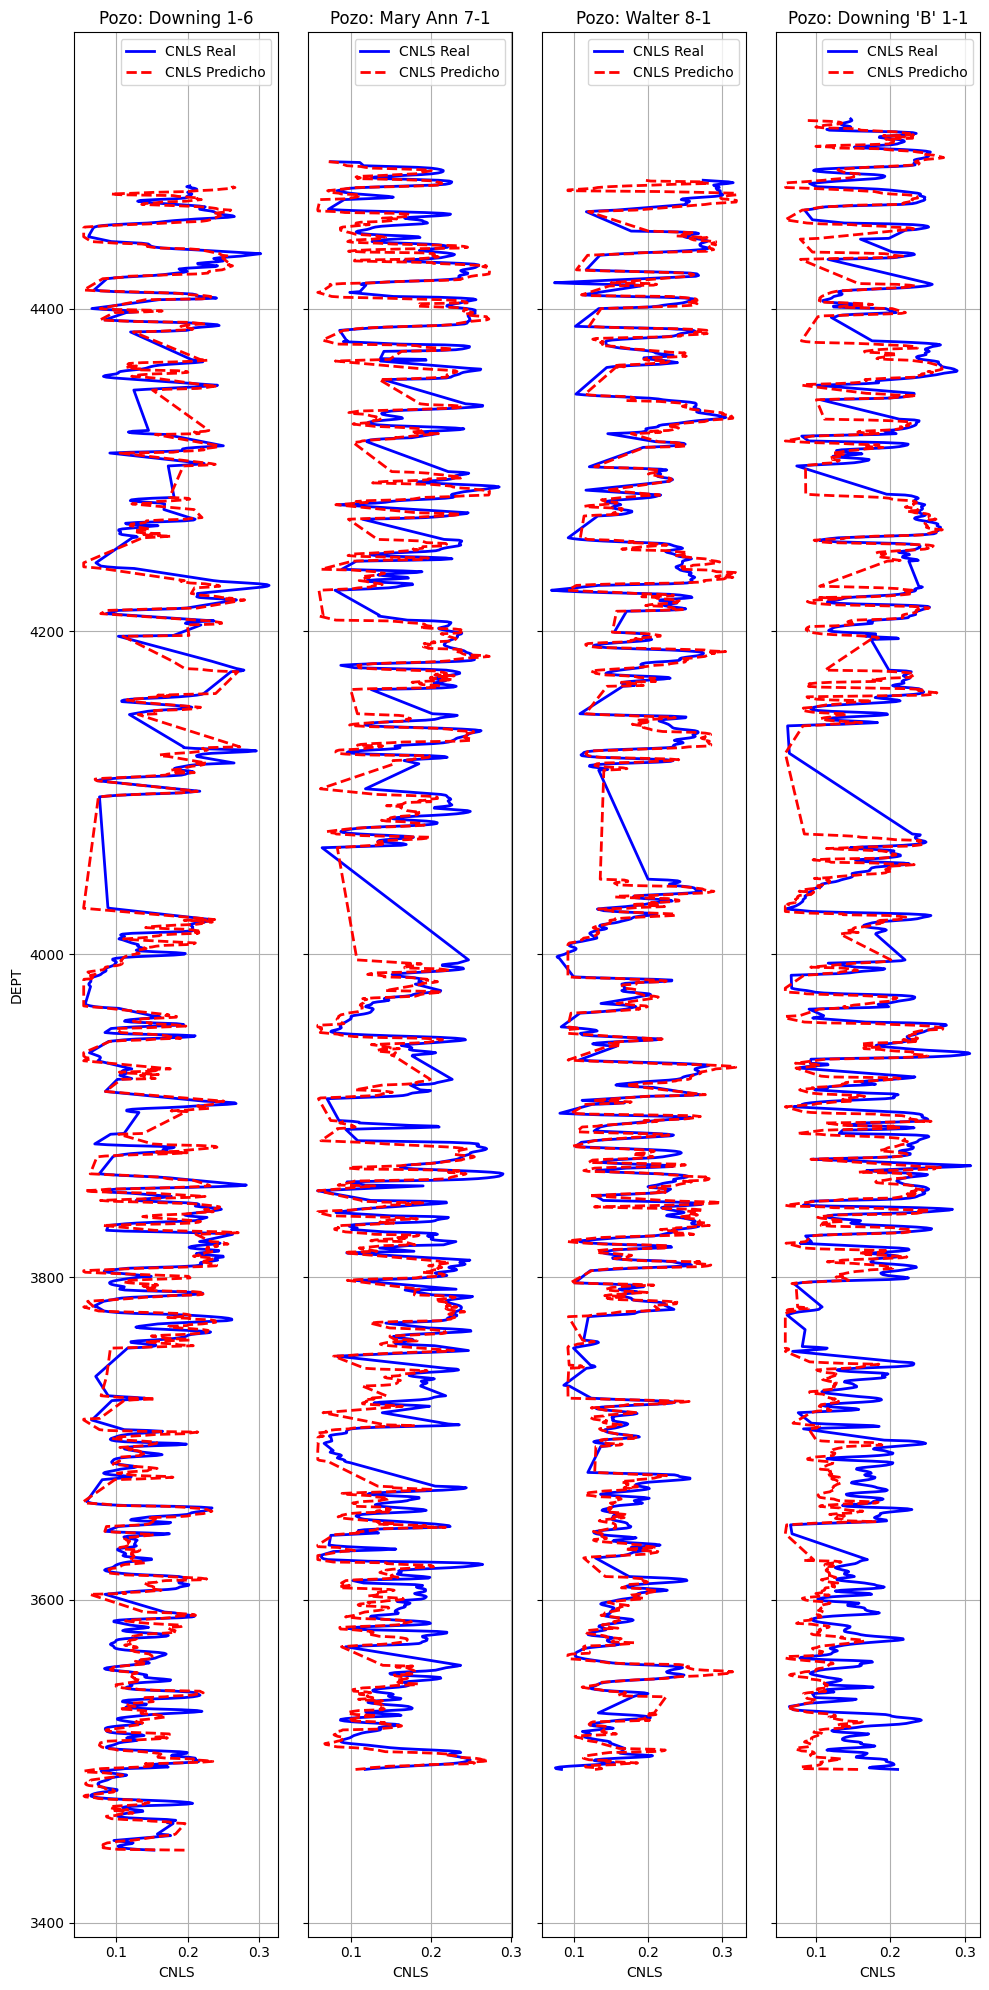

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar el estilo del plot
plt.style.use('default')  # Usar estilo por defecto en lugar de seaborn
fig, axes = plt.subplots(1, len(results_dict), figsize=(10, 20), sharey=True)  # Compartir eje Y

# Crear subplots para cada pozo
n_wells = len(results_dict)

# Si solo hay un pozo, convertir axes a lista para consistencia
if n_wells == 1:
    axes = [axes]

for idx, (well_name, data) in enumerate(results_dict.items()):
    ax = axes[idx]
    
    # Plot CNLS real vs predicho
    dept = np.array(data['DEPT'], dtype=float)
    cnls_real = np.array(data['CNLS'], dtype=float)
    cnls_pred = np.array(data['CNLS_Predicted'], dtype=float)
    
    # Filtrar valores None/NaN - convertir a float primero para usar isnan
    mask = ~np.isnan(cnls_real) & ~np.isnan(cnls_pred) & ~np.isnan(dept)
    dept = dept[mask]
    cnls_real = cnls_real[mask]
    cnls_pred = cnls_pred[mask]
    
    ax.plot(cnls_real, dept, 'b-', label='CNLS Real', linewidth=2)
    ax.plot(cnls_pred, dept, 'r--', label='CNLS Predicho', linewidth=2)
    
    ax.set_title(f'Pozo: {well_name}')
    ax.set_xlabel('CNLS')
    if idx == 0:  # Solo mostrar ylabel en el primer subplot
        ax.set_ylabel('DEPT')
    ax.legend()
    ax.grid(True)
    
    # Invertir eje Y para mostrar profundidad correctamente
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

